## Rachel's Anomaly Plot of Day of Max Temp relative to baseline

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

### Load lSM for doing land vs ocean

In [2]:
file_path = '../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-LSM.nc'
ds_lsm = xr.open_dataset(file_path)
ds_lsm

<xarray.Dataset> Size: 8MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    lsm      (lat, lon) float64 8MB ...

### Load baseline period for climatology 1961-1990

In [3]:
%%time

# takes 40 sec to load

# start with one year and lsm and add a coordinate for the year
year = 1961
input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
ds = xr.open_dataset(input_path)
ds = ds.merge(ds_lsm)
ds = ds.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))

# loop thru remaining years and also add time coord
input_years = np.arange(1962,1991,1)

for year in input_years:
    input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
    ds_i = xr.open_dataset(input_path)
    ds_i = ds_i.merge(ds_lsm)
    ds_i = ds_i.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))
    ds = ds.merge(ds_i)

ds

CPU times: user 15.5 s, sys: 18.9 s, total: 34.4 s
Wall time: 40.5 s


<xarray.Dataset> Size: 2GB
Dimensions:       (lat: 721, lon: 1440, time: 30)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 240B 1961-01-01 ... 1990-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerEnd     (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerTmax    (time, lat, lon) float64 249MB 179.0 179.0 ... 203.0 203.0
    SummerHeat    (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerLength  (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerRMSE    (time, lat, lon) float64 249MB 6.906 6.906 ... 5.745 5.745
    SummerR2      (time, lat, lon) float64 249MB 0.5105 0.5105 ... 0.6524 0.6524
    lsm           (time, lat, lon) float64 249MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0

### Determine average day of mean Tmax during baseline for each grid cell

In [4]:
mean_tmaxday_baseline = ds.SummerTmax.mean(dim='time')
mean_tmaxday_baseline

<xarray.DataArray 'SummerTmax' (lat: 721, lon: 1440)> Size: 8MB
array([[186.96666667, 186.96666667, 186.96666667, ..., 186.96666667,
        186.96666667, 186.96666667],
       [186.76666667, 186.76666667, 186.76666667, ..., 186.76666667,
        186.76666667, 186.76666667],
       [186.3       , 186.3       , 186.3       , ..., 186.6       ,
        186.3       , 186.3       ],
       ...,
       [199.2       , 199.2       , 199.2       , ..., 199.2       ,
        199.2       , 199.2       ],
       [198.26666667, 198.26666667, 198.23333333, ..., 198.26666667,
        198.26666667, 198.26666667],
       [198.6       , 198.6       , 198.6       , ..., 198.6       ,
        198.6       , 198.6       ]])
Coordinates:
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8

### Load analysis period days

In [5]:
%%time

# takes 40 sec to load

# start with one year and lsm and add a coordinate for the year
year = 2000
input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
ds = xr.open_dataset(input_path)
ds = ds.merge(ds_lsm)
ds = ds.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))

# loop thru remaining years and also add time coord
input_years = np.arange(2001,2023,1)

for year in input_years:
    input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
    ds_i = xr.open_dataset(input_path)
    ds_i = ds_i.merge(ds_lsm)
    ds_i = ds_i.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))
    ds = ds.merge(ds_i)

ds

CPU times: user 9.06 s, sys: 9.98 s, total: 19 s
Wall time: 22.3 s


<xarray.Dataset> Size: 2GB
Dimensions:       (lat: 721, lon: 1440, time: 23)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 184B 2000-01-01 ... 2022-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 191MB 156.0 156.0 ... 212.0 212.0
    SummerEnd     (time, lat, lon) float64 191MB 183.0 183.0 ... 242.0 242.0
    SummerTmax    (time, lat, lon) float64 191MB 173.0 173.0 ... 213.0 213.0
    SummerHeat    (time, lat, lon) float64 191MB 6.884e+03 ... 8.191e+03
    SummerLength  (time, lat, lon) float64 191MB 28.0 28.0 28.0 ... 31.0 31.0
    SummerRMSE    (time, lat, lon) float64 191MB 8.086 8.086 ... 4.992 4.992
    SummerR2      (time, lat, lon) float64 191MB 0.5254 0.5254 ... 0.7734 0.7734
    lsm           (time, lat, lon) float64 191MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0

### Determine average day of mean Tmax during 2000-2022 for each grid cell

In [6]:
mean_tmaxday_analysis = ds.SummerTmax.mean(dim='time')
mean_tmaxday_analysis

<xarray.DataArray 'SummerTmax' (lat: 721, lon: 1440)> Size: 8MB
array([[182.65217391, 182.65217391, 182.65217391, ..., 182.65217391,
        182.65217391, 182.65217391],
       [180.91304348, 180.91304348, 180.91304348, ..., 180.91304348,
        180.91304348, 180.91304348],
       [181.52173913, 181.52173913, 181.52173913, ..., 181.08695652,
        181.30434783, 181.52173913],
       ...,
       [202.65217391, 202.65217391, 202.65217391, ..., 202.7826087 ,
        202.7826087 , 202.65217391],
       [202.7826087 , 202.7826087 , 202.7826087 , ..., 202.82608696,
        202.82608696, 202.82608696],
       [202.26086957, 202.26086957, 202.26086957, ..., 202.26086957,
        202.26086957, 202.26086957]])
Coordinates:
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8

### Subtract for anomaly between analysis and baseline and create map

In [8]:
tmax_anomaly = mean_tmaxday_analysis - mean_tmaxday_baseline
tmax_anomaly

<xarray.DataArray 'SummerTmax' (lat: 721, lon: 1440)> Size: 8MB
array([[-4.31449275, -4.31449275, -4.31449275, ..., -4.31449275,
        -4.31449275, -4.31449275],
       [-5.85362319, -5.85362319, -5.85362319, ..., -5.85362319,
        -5.85362319, -5.85362319],
       [-4.77826087, -4.77826087, -4.77826087, ..., -5.51304348,
        -4.99565217, -4.77826087],
       ...,
       [ 3.45217391,  3.45217391,  3.45217391, ...,  3.5826087 ,
         3.5826087 ,  3.45217391],
       [ 4.51594203,  4.51594203,  4.54927536, ...,  4.55942029,
         4.55942029,  4.55942029],
       [ 3.66086957,  3.66086957,  3.66086957, ...,  3.66086957,
         3.66086957,  3.66086957]])
Coordinates:
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8

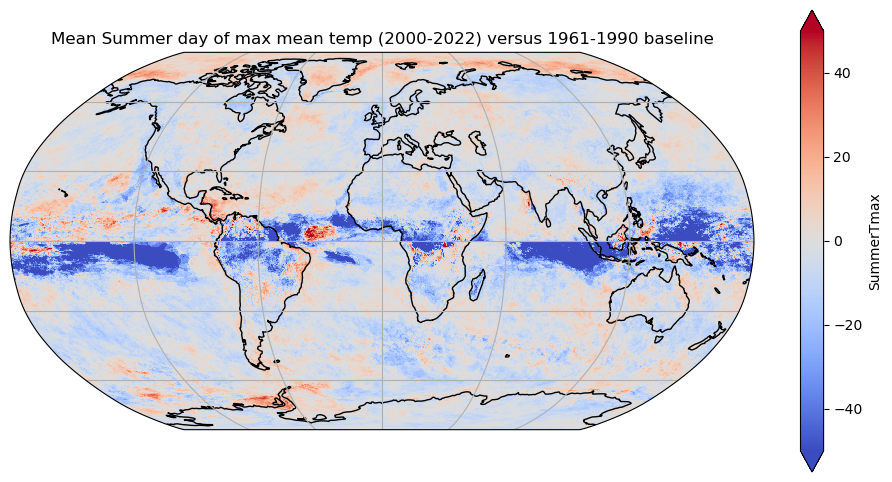

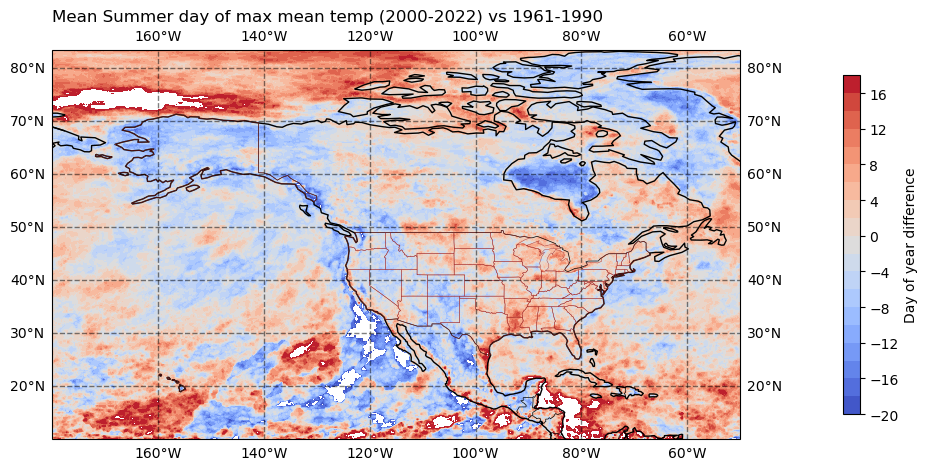

In [10]:


############
#Global map of tmax anomaly
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

tmax_anomaly.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-50,
    vmax=50, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Mean Summer day of max mean temp (2000-2022) versus 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerHeat_global.png")
plt.show()



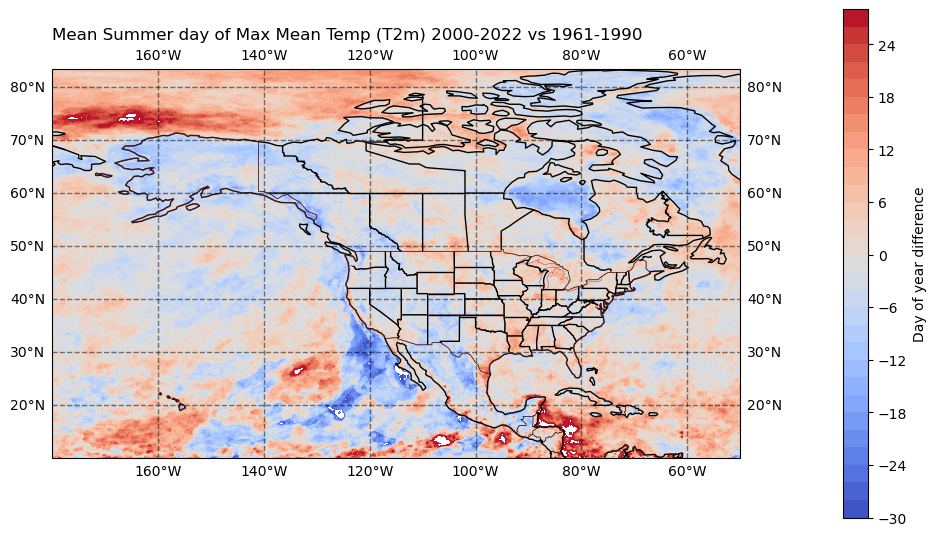

CPU times: user 8min 34s, sys: 453 ms, total: 8min 34s
Wall time: 8min 36s


In [17]:
%%time

provinces_50m = cfeature.NaturalEarthFeature('cultural',
                                             'admin_1_states_provinces_lines',
                                             '50m',
                                             facecolor='none')

central_longitude = -(91 + 52 / 60)

#North america map too
fig = plt.figure(figsize=(12,12))
ax = plt.subplot(1,1,1, projection=ccrs.PlateCarree(central_longitude=central_longitude))  
ax.set_title("Mean Summer day of Max Mean Temp (T2m) 2000-2022 vs 1961-1990", loc="left")
dataplot = ax.contourf(
    tmax_anomaly.lon,
    tmax_anomaly.lat,
    tmax_anomaly,
    levels=np.arange(-30,30,2),
    transform=ccrs.PlateCarree(),#PlateCarree(),
    cmap=plt.cm.coolwarm,
)
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')
ax.set_extent((-180, -50, 10, 75))
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
ax.add_feature(provinces_50m)
fig.colorbar(dataplot, orientation="vertical", label="Day of year difference",
             shrink=0.55, pad=0.11
            )
#plt.savefig("./Plots/"+str(input_year)+"_SummerHeat_NA.png")
plt.show()